# Feature Engineering — `factory_final.csv`

**Objective**: Implement feature engineering steps identified from EDA (notebook 02) and multicollinearity analysis (notebook 03).

**Steps:**
1. Log-transform target — fixes residual distribution for linear models
2. Log-transform `Area (sqft)` — fixes linearity assumption (skewness=+3.947)
3. Lease Remaining Ratio — captures proportional lease life; drop `Lease_Duration`
4. Verify VIF on updated feature set
5. Save engineered dataset

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/factory_final.csv")

TARGET = "Unit Price ($ psf)"

print(f"Dataset shape: {df.shape}")
print(f"Target — Mean: ${df[TARGET].mean():.2f} | Median: ${df[TARGET].median():.2f} | Skewness: {df[TARGET].skew():.3f}")
print(f"Area   — Mean: {df['Area (sqft)'].mean():.1f} | Median: {df['Area (sqft)'].median():.1f} | Skewness: {df['Area (sqft)'].skew():.3f}")

Dataset shape: (3782, 25)
Target — Mean: $441.69 | Median: $435.00 | Skewness: 0.823
Area   — Mean: 2474.1 | Median: 1765.0 | Skewness: 3.947


## 2. Log-Transform Target

**Why**: Target is right-skewed (skewness=+0.82). Linear regression assumes normally distributed, homoscedastic residuals — a skewed target breaks both. Log-transform fixes the residual distribution.

**Only for linear models** — tree-based models are unaffected by target skewness.

**Back-transform**: After predicting in log-space, use `exp()` to return to dollar values.

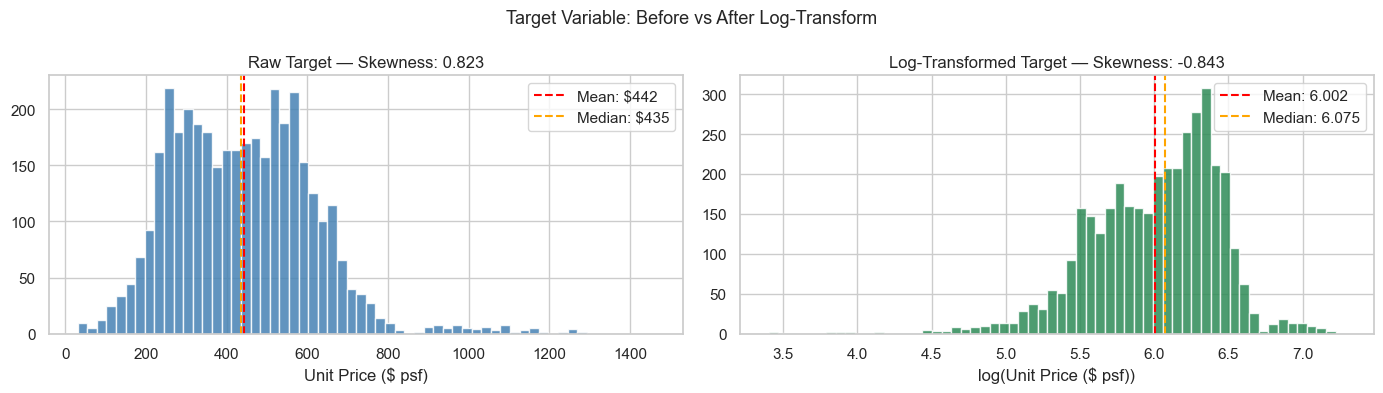

Raw target — Skewness: 0.823
Log target — Skewness: -0.843


In [2]:
df["Log_Unit_Price"] = np.log(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[TARGET], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--", label=f"Mean: ${df[TARGET].mean():.0f}")
axes[0].axvline(df[TARGET].median(), color="orange", linestyle="--", label=f"Median: ${df[TARGET].median():.0f}")
axes[0].set_title(f"Raw Target — Skewness: {df[TARGET].skew():.3f}")
axes[0].set_xlabel("Unit Price ($ psf)")
axes[0].legend()

axes[1].hist(df["Log_Unit_Price"], bins=60, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].axvline(df["Log_Unit_Price"].mean(), color="red", linestyle="--", label=f"Mean: {df['Log_Unit_Price'].mean():.3f}")
axes[1].axvline(df["Log_Unit_Price"].median(), color="orange", linestyle="--", label=f"Median: {df['Log_Unit_Price'].median():.3f}")
axes[1].set_title(f"Log-Transformed Target — Skewness: {df['Log_Unit_Price'].skew():.3f}")
axes[1].set_xlabel("log(Unit Price ($ psf))")
axes[1].legend()

plt.suptitle("Target Variable: Before vs After Log-Transform", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw target — Skewness: {df[TARGET].skew():.3f}")
print(f"Log target — Skewness: {df['Log_Unit_Price'].skew():.3f}")

## 3. Log-Transform `Area (sqft)`

**Why**: `Area (sqft)` is severely right-skewed (skewness=+3.947, max=22,314 vs median=1,765). For features, log-transform fixes the **linearity assumption** — linear regression expects a straight-line relationship between each feature and the target. A skewed feature produces a curved relationship. Log-transforming straightens it.

**Key distinction from target transform**:
- Log-transform target → fixes **residual distribution**
- Log-transform feature → fixes **linearity assumption**

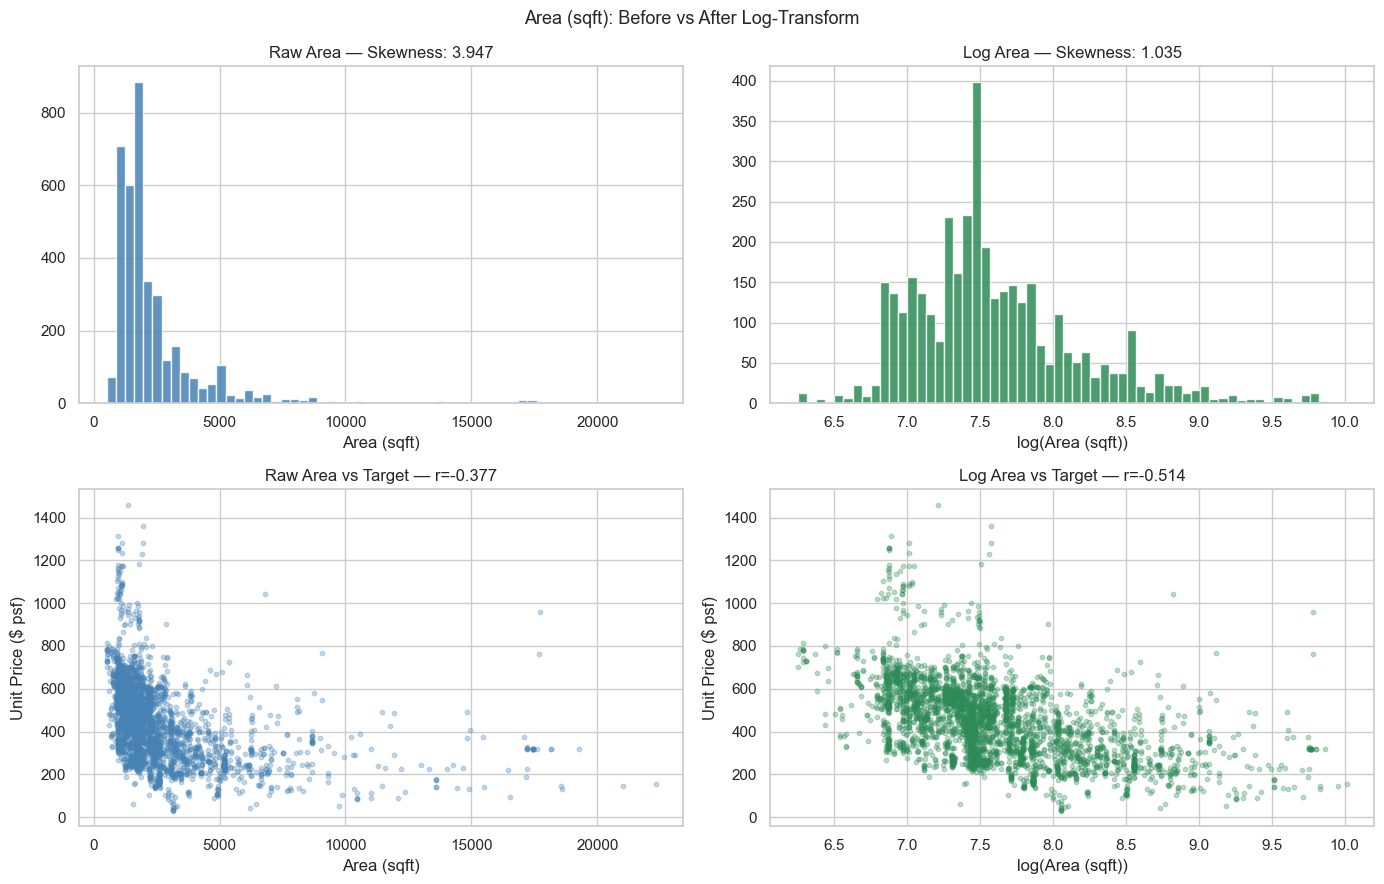

Raw Area  — Skewness: 3.947 | Correlation with target: -0.377
Log Area  — Skewness: 1.035 | Correlation with target: -0.514


In [3]:
df["Log_Area"] = np.log(df["Area (sqft)"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Raw Area distribution
axes[0, 0].hist(df["Area (sqft)"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0, 0].set_title(f"Raw Area — Skewness: {df['Area (sqft)'].skew():.3f}")
axes[0, 0].set_xlabel("Area (sqft)")

# Log Area distribution
axes[0, 1].hist(df["Log_Area"], bins=60, color="seagreen", edgecolor="white", alpha=0.85)
axes[0, 1].set_title(f"Log Area — Skewness: {df['Log_Area'].skew():.3f}")
axes[0, 1].set_xlabel("log(Area (sqft))")

# Raw Area vs Target
axes[1, 0].scatter(df["Area (sqft)"], df[TARGET], alpha=0.3, s=10, color="steelblue")
axes[1, 0].set_xlabel("Area (sqft)")
axes[1, 0].set_ylabel("Unit Price ($ psf)")
axes[1, 0].set_title(f"Raw Area vs Target — r={df['Area (sqft)'].corr(df[TARGET]):.3f}")

# Log Area vs Target
axes[1, 1].scatter(df["Log_Area"], df[TARGET], alpha=0.3, s=10, color="seagreen")
axes[1, 1].set_xlabel("log(Area (sqft))")
axes[1, 1].set_ylabel("Unit Price ($ psf)")
axes[1, 1].set_title(f"Log Area vs Target — r={df['Log_Area'].corr(df[TARGET]):.3f}")

plt.suptitle("Area (sqft): Before vs After Log-Transform", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw Area  — Skewness: {df['Area (sqft)'].skew():.3f} | Correlation with target: {df['Area (sqft)'].corr(df[TARGET]):.3f}")
print(f"Log Area  — Skewness: {df['Log_Area'].skew():.3f} | Correlation with target: {df['Log_Area'].corr(df[TARGET]):.3f}")

## 4. Lease Remaining Ratio

**Why**: Both `Remaining_Lease_Years` (r=+0.672) and `Lease_Duration` (r=+0.586) are strong predictors, but neither captures the proportional relationship. A property with 30 years on a 60-year lease (50% remaining) is very different from one with 30 years on a 99-year lease (30% remaining).

**Design decision**:
- Keep `Remaining_Lease_Years` — captures absolute lease life remaining
- Keep `Lease_Remaining_Ratio` — captures proportional lease life consumed
- Drop `Lease_Duration` — redundant once ratio is present

**Caveat**: VIF must be rechecked after this change.

Correlation with target:
  Remaining_Lease_Years:  r = 0.672
  Lease_Duration:         r = 0.586
  Lease_Remaining_Ratio:  r = 0.326


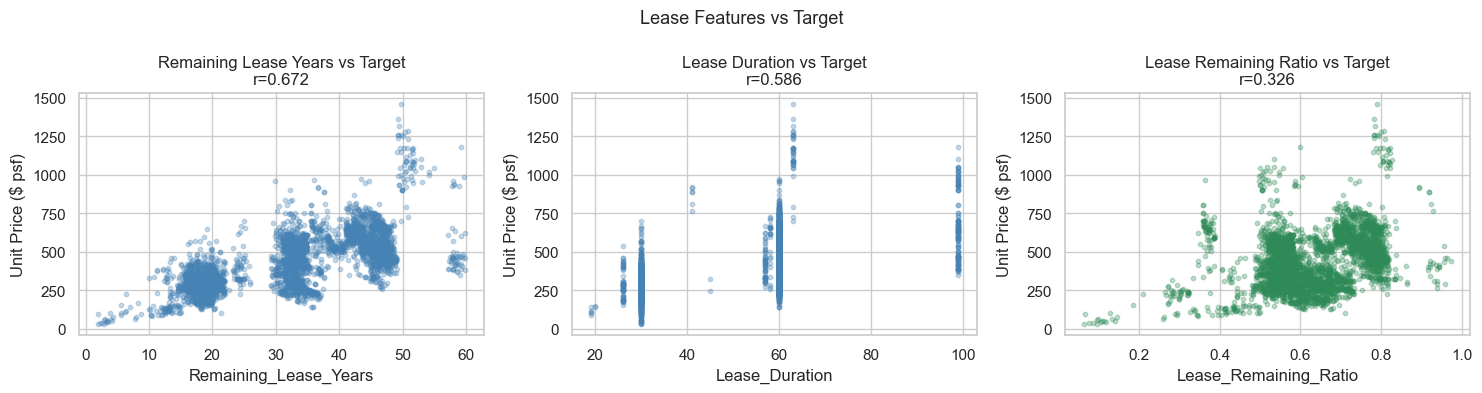

In [4]:
df["Lease_Remaining_Ratio"] = df["Remaining_Lease_Years"] / df["Lease_Duration"]

r_ratio = df["Lease_Remaining_Ratio"].corr(df[TARGET])
r_remaining = df["Remaining_Lease_Years"].corr(df[TARGET])
r_duration = df["Lease_Duration"].corr(df[TARGET])

print("Correlation with target:")
print(f"  Remaining_Lease_Years:  r = {r_remaining:.3f}")
print(f"  Lease_Duration:         r = {r_duration:.3f}")
print(f"  Lease_Remaining_Ratio:  r = {r_ratio:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df["Remaining_Lease_Years"], df[TARGET], alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Remaining_Lease_Years")
axes[0].set_ylabel("Unit Price ($ psf)")
axes[0].set_title(f"Remaining Lease Years vs Target\nr={r_remaining:.3f}")

axes[1].scatter(df["Lease_Duration"], df[TARGET], alpha=0.3, s=10, color="steelblue")
axes[1].set_xlabel("Lease_Duration")
axes[1].set_ylabel("Unit Price ($ psf)")
axes[1].set_title(f"Lease Duration vs Target\nr={r_duration:.3f}")

axes[2].scatter(df["Lease_Remaining_Ratio"], df[TARGET], alpha=0.3, s=10, color="seagreen")
axes[2].set_xlabel("Lease_Remaining_Ratio")
axes[2].set_ylabel("Unit Price ($ psf)")
axes[2].set_title(f"Lease Remaining Ratio vs Target\nr={r_ratio:.3f}")

plt.suptitle("Lease Features vs Target", fontsize=13)
plt.tight_layout()
plt.show()

## 5. VIF Check — Updated Feature Set

Verify that VIF remains acceptable after:
- Adding `Lease_Remaining_Ratio`
- Dropping `Lease_Duration`
- Replacing `Area (sqft)` with `Log_Area`

In [5]:
FEATURE_COLS_ENGINEERED = [
    "Log_Area",
    "Remaining_Lease_Years", "Lease_Remaining_Ratio",
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    "10Y_Bond_Yield", "SORA_3M_Compounded", "Cement_Bulk_Per_Tonne"
]

def compute_vif(feature_df):
    X = StandardScaler().fit_transform(feature_df)
    vif_vals = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    result = pd.DataFrame({
        "Feature": feature_df.columns,
        "VIF": np.round(vif_vals, 2)
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    result["Flag"] = result["VIF"].apply(
        lambda v: "HIGH" if v > 10 else ("WATCH" if v > 5 else "OK")
    )
    return result

def highlight_vif(row):
    if row["Flag"] == "HIGH":
        return ["background-color: #ffcccc"] * len(row)
    elif row["Flag"] == "WATCH":
        return ["background-color: #fff3cc"] * len(row)
    return [""] * len(row)

vif_result = compute_vif(df[FEATURE_COLS_ENGINEERED].dropna())
print(f"VIF — Engineered Feature Set ({len(FEATURE_COLS_ENGINEERED)} features)")
display(vif_result.style.apply(highlight_vif, axis=1))

max_vif = vif_result["VIF"].max()
print(f"\nMax VIF: {max_vif:.2f} — {'ACCEPTABLE (all < 10)' if max_vif < 10 else 'ACTION REQUIRED'}")

VIF — Engineered Feature Set (9 features)


,Feature,VIF,Flag
0,CPI_All_Items,9.310000,WATCH
1,SORA_3M_Compounded,6.940000,WATCH
2,10Y_Bond_Yield,4.840000,OK
3,GDP_YoY_Growth_Rate,4.230000,OK
4,Cement_Bulk_Per_Tonne,3.740000,OK
5,Remaining_Lease_Years,1.450000,OK
6,Lease_Remaining_Ratio,1.410000,OK
7,Unemployment_Rate,1.360000,OK
8,Log_Area,1.070000,OK



Max VIF: 9.31 — ACCEPTABLE (all < 10)


## 6. Summary

In [6]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print("""
[STEP 1] Log-transform target
  Raw skewness:  {:.3f}
  Log skewness:  {:.3f}
  New column:    Log_Unit_Price
  Use for:       Linear models only
""".format(df[TARGET].skew(), df["Log_Unit_Price"].skew()))

print("""
[STEP 2] Log-transform Area (sqft)
  Raw skewness:  {:.3f}
  Log skewness:  {:.3f}
  Raw corr:      {:.3f}
  Log corr:      {:.3f}
  New column:    Log_Area (replaces Area (sqft))
""".format(
    df["Area (sqft)"].skew(), df["Log_Area"].skew(),
    df["Area (sqft)"].corr(df[TARGET]), df["Log_Area"].corr(df[TARGET])
))

print("""
[STEP 3] Lease Remaining Ratio
  Formula:       Remaining_Lease_Years / Lease_Duration
  Correlation:   {:.3f}
  New column:    Lease_Remaining_Ratio
  Dropped:       Lease_Duration (redundant)
""".format(df["Lease_Remaining_Ratio"].corr(df[TARGET])))

print("[FINAL FEATURE SET]")
for col in FEATURE_COLS_ENGINEERED:
    r = df[col].corr(df[TARGET])
    print(f"  {col:<30}  r = {r:+.3f}")

print(f"""
[TARGETS]
  Linear models:  Log_Unit_Price (back-transform via exp())
  Tree models:    Unit Price ($ psf) (no transform needed)
""")

FEATURE ENGINEERING SUMMARY

[STEP 1] Log-transform target
  Raw skewness:  0.823
  Log skewness:  -0.843
  New column:    Log_Unit_Price
  Use for:       Linear models only


[STEP 2] Log-transform Area (sqft)
  Raw skewness:  3.947
  Log skewness:  1.035
  Raw corr:      -0.377
  Log corr:      -0.514
  New column:    Log_Area (replaces Area (sqft))


[STEP 3] Lease Remaining Ratio
  Formula:       Remaining_Lease_Years / Lease_Duration
  Correlation:   0.326
  New column:    Lease_Remaining_Ratio
  Dropped:       Lease_Duration (redundant)

[FINAL FEATURE SET]
  Log_Area                        r = -0.514
  Remaining_Lease_Years           r = +0.672
  Lease_Remaining_Ratio           r = +0.326
  GDP_YoY_Growth_Rate             r = +0.061
  CPI_All_Items                   r = +0.103
  Unemployment_Rate               r = -0.004
  10Y_Bond_Yield                  r = -0.062
  SORA_3M_Compounded              r = -0.080
  Cement_Bulk_Per_Tonne           r = -0.072

[TARGETS]
  Linear model

## 7. Save Engineered Dataset

In [7]:
# Columns to retain in engineered dataset
# Drop: Area (sqft) — replaced by Log_Area
#        Lease_Duration — replaced by Lease_Remaining_Ratio
#        Postal District, Postal Sector — numerical codes, not features
#        Year, Month, Quarter — mapping keys only

DROP_COLS = ["Area (sqft)", "Lease_Duration", "Postal District", "Postal Sector",
             "Year", "Month", "Quarter"]

df_engineered = df.drop(columns=DROP_COLS)

output_path = "../data/processed/factory_engineered.csv"
df_engineered.to_csv(output_path, index=False)

print(f"Engineered dataset saved to: {output_path}")
print(f"Shape: {df_engineered.shape}")
print(f"\nColumns retained ({len(df_engineered.columns)}):")
for col in df_engineered.columns:
    print(f"  {col}")

Engineered dataset saved to: ../data/processed/factory_engineered.csv


Shape: (3782, 21)

Columns retained (21):
  Contract Date
  Project Name
  Street Name
  Type Of Area
  Floor Level
  Unit Price ($ psf)
  Type of Sale
  Region
  Planning Area
  Remaining_Lease_Years
  GDP_YoY_Growth_Rate
  CPI_All_Items
  Unemployment_Rate
  Price_Index
  10Y_Bond_Yield
  SORA_3M_Compounded
  Cement_Bulk_Per_Tonne
  Steel_Rebar_Per_Tonne
  Log_Unit_Price
  Log_Area
  Lease_Remaining_Ratio
